In [321]:
import datetime
import pingouin as pg
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import phik
import scipy.stats as stats
import seaborn as sns
import statsmodels.api as sm
import warnings
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')
%config InlineBackend.figure_format = 'retina'
sns.set_theme(context='talk', style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = 10, 7
plt.rcParams['font.size'] = 20
plt.rcParams['axes.labelsize'] = 25
plt.rcParams['figure.titlesize'] = 32
plt.rcParams['axes.titlesize'] = 32
plt.rcParams['savefig.format'] = 'pdf'
plt.rcParams['figure.autolayout'] = 'true'
plt.rcParams['figure.frameon'] = 'false'
plt.rcParams['axes.spines.left'] = 'false'
plt.rcParams['axes.spines.right'] = 'false'
plt.rcParams['axes.spines.top'] = 'false'
plt.rcParams['legend.fancybox'] = 'false'
plt.rcParams['axes.spines.bottom'] = 'false'
plt.rcParams['font.size'] = 20
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
# для графиков, где надо много цветов, юзайте воть:
sns.set_palette(sns.color_palette('deep'))
# а по дефолту воть:
sns.set_palette(sns.color_palette('BuGn_r', n_colors=10)[2::3])
pd.set_option('display.max_columns', 60)

monthly_feeding = pd.read_excel('datasets/Ekoniva_dataset.xlsx', sheet_name='Feeding')
herd_metrics = pd.read_excel('datasets/Ekoniva_dataset.xlsx', sheet_name='Herd maintenance').replace('-', np.nan)
production_indicators = pd.read_excel('datasets/Ekoniva_dataset.xlsx', sheet_name='Dairy indicators').replace('-', np.nan)

herd_metrics["year_month"] = herd_metrics["date"].dt.to_period('M').astype(str)

fad = pd.read_csv("datasets//FeedingAndDetails_clear.csv", index_col=0)

fad["Date"] = pd.to_datetime(fad["Date"])
fad["year_month"] = fad["Date"].dt.to_period('M').astype(str)
fad = fad.rename(columns={"FarmName": "farm_name"})


In [322]:
herd_metrics = herd_metrics[~((herd_metrics['calves']==0) & (herd_metrics['cow_metrit']!=0))]

In [323]:
"""mapsda = {
    'ЖК Бортниково': 'Москва',
    'ЖК Зимитицы': 'Санкт-Петербург',
    'ЖК Плеханово': 'Тюмень',
    'МТФ Гилево': 'Тюмень'
}
herd_metrics['region'] = herd_metrics['farm_name'].map(mapsda).fillna(herd_metrics['region'])"""

"mapsda = {\n    'ЖК Бортниково': 'Москва',\n    'ЖК Зимитицы': 'Санкт-Петербург',\n    'ЖК Плеханово': 'Тюмень',\n    'МТФ Гилево': 'Тюмень'\n}\nherd_metrics['region'] = herd_metrics['farm_name'].map(mapsda).fillna(herd_metrics['region'])"

In [325]:
def explode_monthly_to_daily(
    df_monthly,
    value_col,
    output_col,
    normalize_by=None,
):
    """
    Равномерно распределяет месячное значение по дням месяца.

    df_monthly:
        farm_name
        year_month (YYYY-MM)
        value_col       – cow_metrit / calves / etc
        normalize_by    – колонка, на которую делим (например calves)

    output:
        farm_name
        date
        output_col      – значение НА ДЕНЬ
    """
    df = df_monthly.copy()
    df["year_month"] = pd.to_datetime(df["year_month"], format="%Y-%m", errors="coerce")
    df["days_in_month"] = df["year_month"].dt.days_in_month

    # считаем дневное значение
    if normalize_by:
        valid = (df[value_col] >= 0) & (df[normalize_by] > 0)
        df[output_col] = np.nan

        df.loc[valid, output_col] = (
            df.loc[valid, value_col] /
            df.loc[valid, normalize_by] /
            df.loc[valid, "days_in_month"]
        )

        error_mask = (df[value_col] > 0) & (df[normalize_by] == 0)
        if error_mask.any():
            print(f"WARNING: {value_col}>0 и {normalize_by}=0:")
            print(df.loc[error_mask, ["farm_name", "year_month", value_col, normalize_by]])
    else:
        df[output_col] = df[value_col] / df["days_in_month"]

    rows = []
    for _, row in df.iterrows():
        dates = pd.date_range(
            start=row["year_month"],
            end=row["year_month"] + pd.offsets.MonthEnd(0),
            freq="D"
        )
        for d in dates:
            rows.append({
                "farm_name": row["farm_name"],
                "date": d,
                output_col: row[output_col],
            })

    daily_df = pd.DataFrame(rows)
    daily_df.replace([np.inf, -np.inf], np.nan, inplace=True)

    return daily_df


In [326]:
daily_metrit_df = explode_monthly_to_daily(
    df_monthly=herd_metrics,
    value_col="cow_metrit",
    output_col="metrit",
)
daily_metrit_df

,farm_name,date,metrit
0,ЖК Бобров,2020-01-01,NaN
1,ЖК Бобров,2020-01-02,NaN
2,ЖК Бобров,2020-01-03,NaN
3,ЖК Бобров,2020-01-04,NaN
4,ЖК Бобров,2020-01-05,NaN
...,...,...,...
130518,ЖК Курочкино,2025-07-27,2.387097
130519,ЖК Курочкино,2025-07-28,2.387097
130520,ЖК Курочкино,2025-07-29,2.387097
130521,ЖК Курочкино,2025-07-30,2.387097


<Axes: xlabel='metrit', ylabel='Count'>

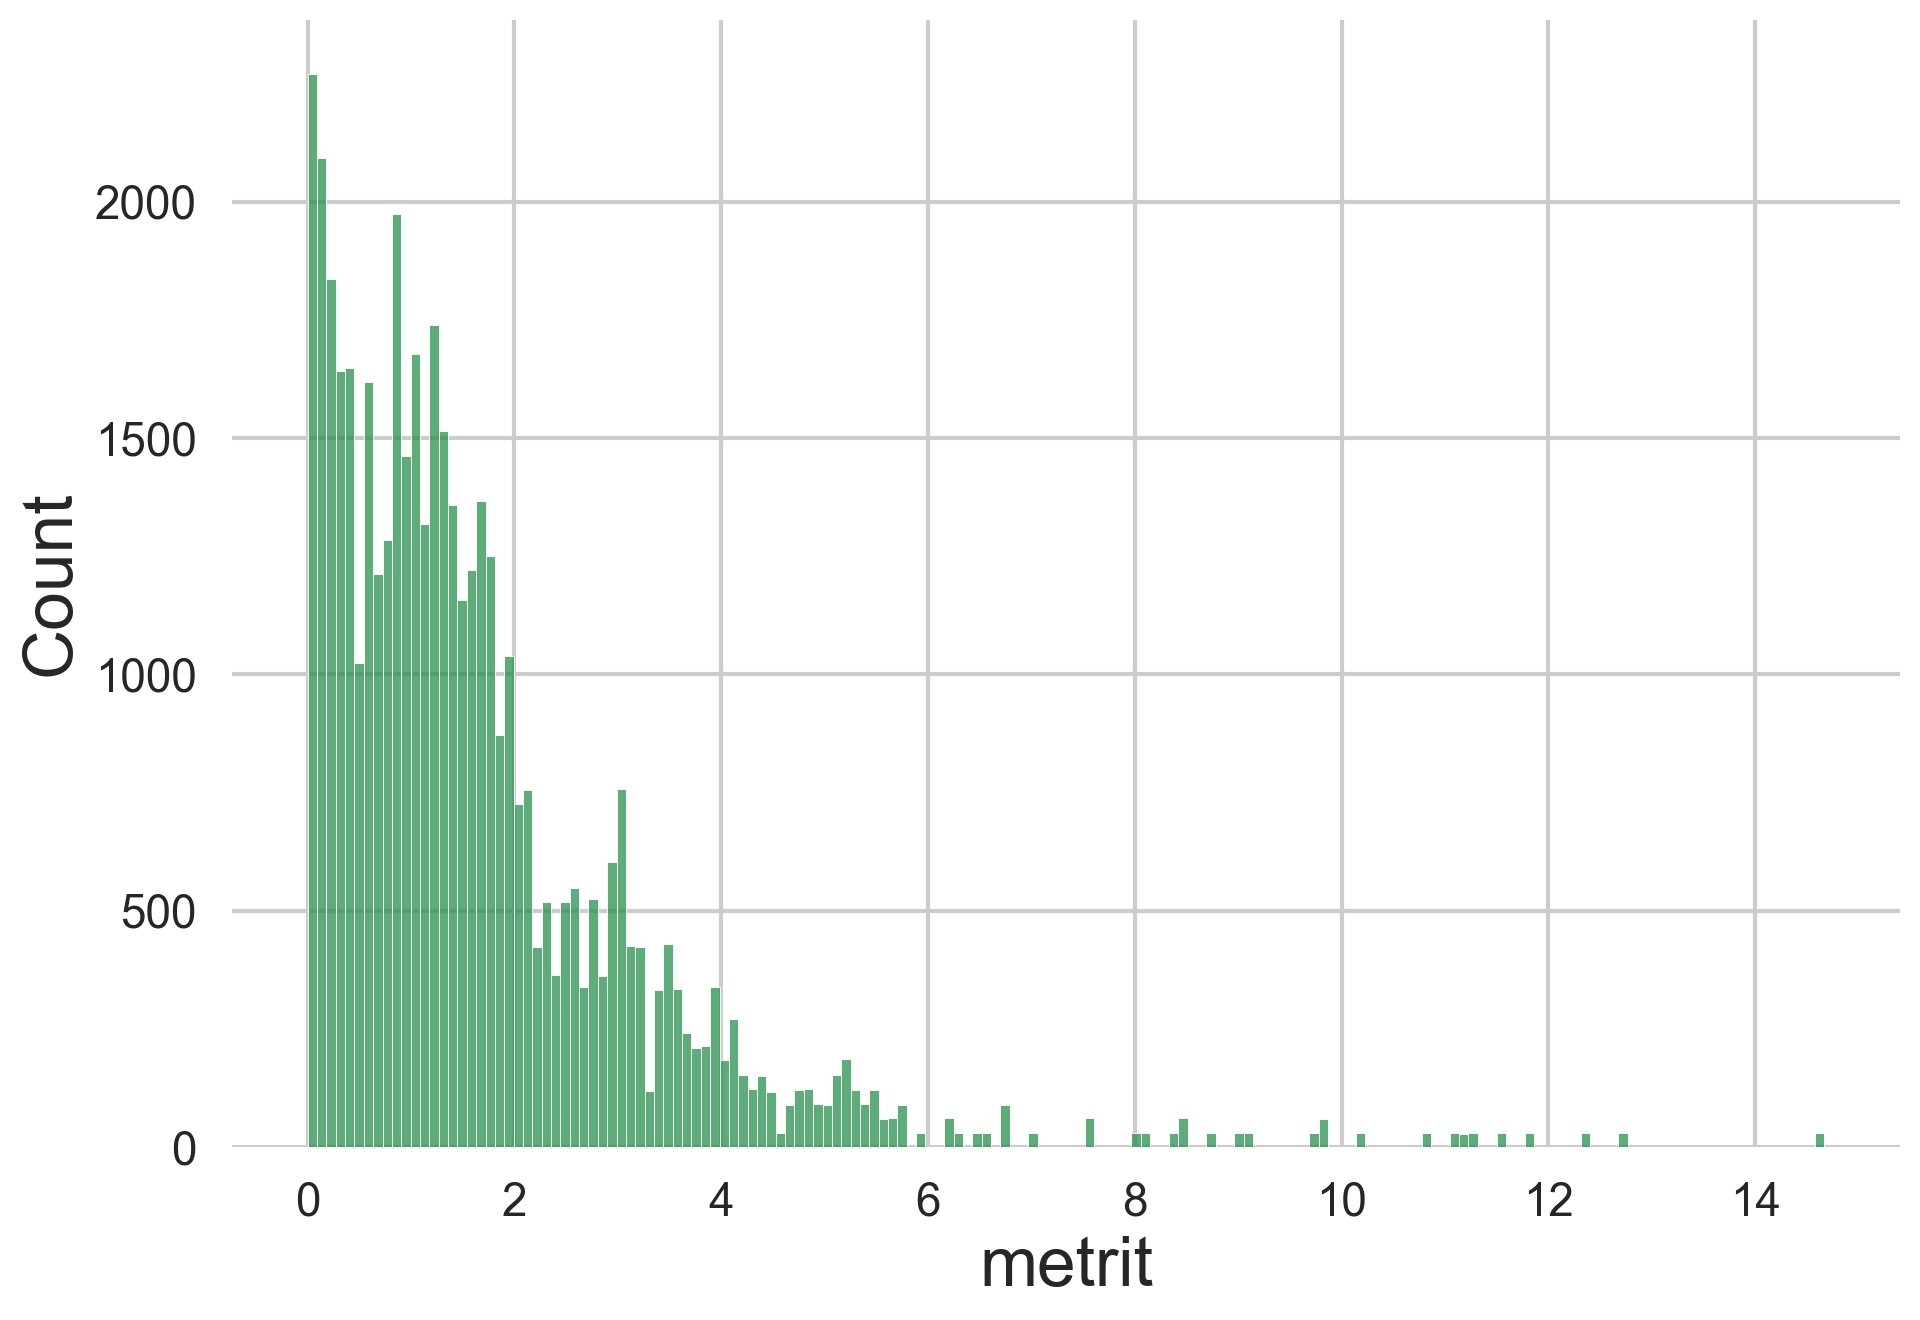

In [327]:
sns.histplot(daily_metrit_df, x="metrit")

In [328]:
daily_calves_df = explode_monthly_to_daily(
    df_monthly=herd_metrics,
    value_col="calves",
    output_col="calves",
)
daily_calves_df

,farm_name,date,calves
0,ЖК Бобров,2020-01-01,NaN
1,ЖК Бобров,2020-01-02,NaN
2,ЖК Бобров,2020-01-03,NaN
3,ЖК Бобров,2020-01-04,NaN
4,ЖК Бобров,2020-01-05,NaN
...,...,...,...
130518,ЖК Курочкино,2025-07-27,11.580645
130519,ЖК Курочкино,2025-07-28,11.580645
130520,ЖК Курочкино,2025-07-29,11.580645
130521,ЖК Курочкино,2025-07-30,11.580645


<Axes: xlabel='calves', ylabel='Count'>

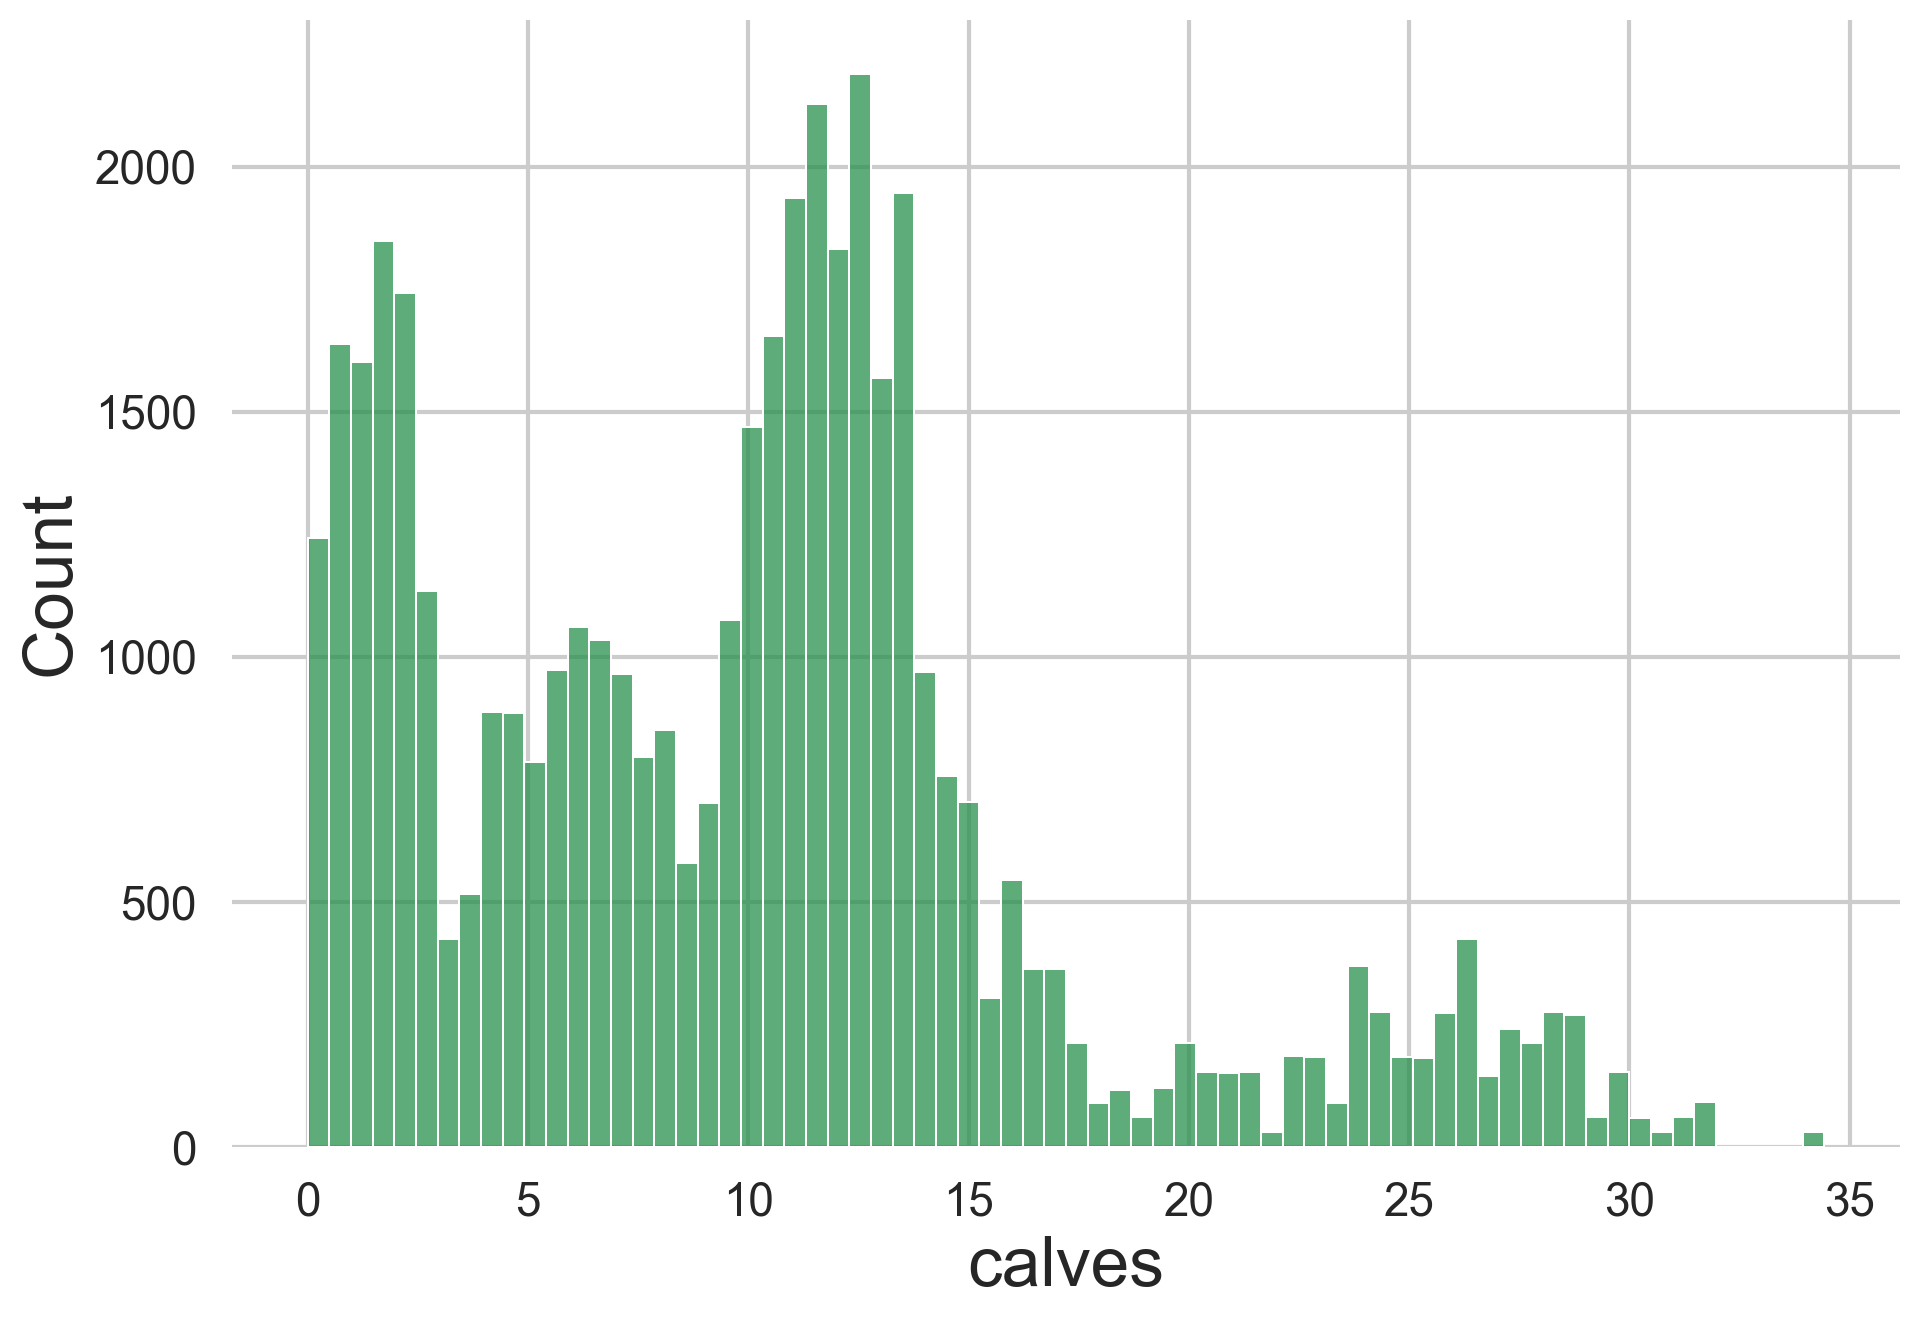

In [329]:
sns.histplot(daily_calves_df, x="calves")

In [330]:
daily_metrit_df["date"] = daily_metrit_df["date"] - pd.DateOffset(days=4)
daily_metrit_df

,farm_name,date,metrit
0,ЖК Бобров,2019-12-28,NaN
1,ЖК Бобров,2019-12-29,NaN
2,ЖК Бобров,2019-12-30,NaN
3,ЖК Бобров,2019-12-31,NaN
4,ЖК Бобров,2020-01-01,NaN
...,...,...,...
130518,ЖК Курочкино,2025-07-23,2.387097
130519,ЖК Курочкино,2025-07-24,2.387097
130520,ЖК Курочкино,2025-07-25,2.387097
130521,ЖК Курочкино,2025-07-26,2.387097


In [331]:
metrit_daily = daily_calves_df.merge(daily_metrit_df, on=["farm_name", "date"])
metrit_daily["cow_metrit_per_day"] = metrit_daily["metrit"] / metrit_daily["calves"]
metrit_daily = metrit_daily[~metrit_daily["cow_metrit_per_day"].isna()]
metrit_daily

,farm_name,date,calves,metrit,cow_metrit_per_day
70121,ЖК Бобров,2023-01-01,9.612903,1.935484,0.201342
70122,ЖК Бобров,2023-01-02,9.612903,1.935484,0.201342
70123,ЖК Бобров,2023-01-03,9.612903,1.935484,0.201342
70124,ЖК Бобров,2023-01-04,9.612903,1.935484,0.201342
70125,ЖК Бобров,2023-01-05,9.612903,1.935484,0.201342
...,...,...,...,...,...
130134,ЖК Курочкино,2025-07-23,11.580645,2.387097,0.206128
130135,ЖК Курочкино,2025-07-24,11.580645,2.387097,0.206128
130136,ЖК Курочкино,2025-07-25,11.580645,2.387097,0.206128
130137,ЖК Курочкино,2025-07-26,11.580645,2.387097,0.206128


<Axes: xlabel='cow_metrit_per_day', ylabel='Count'>

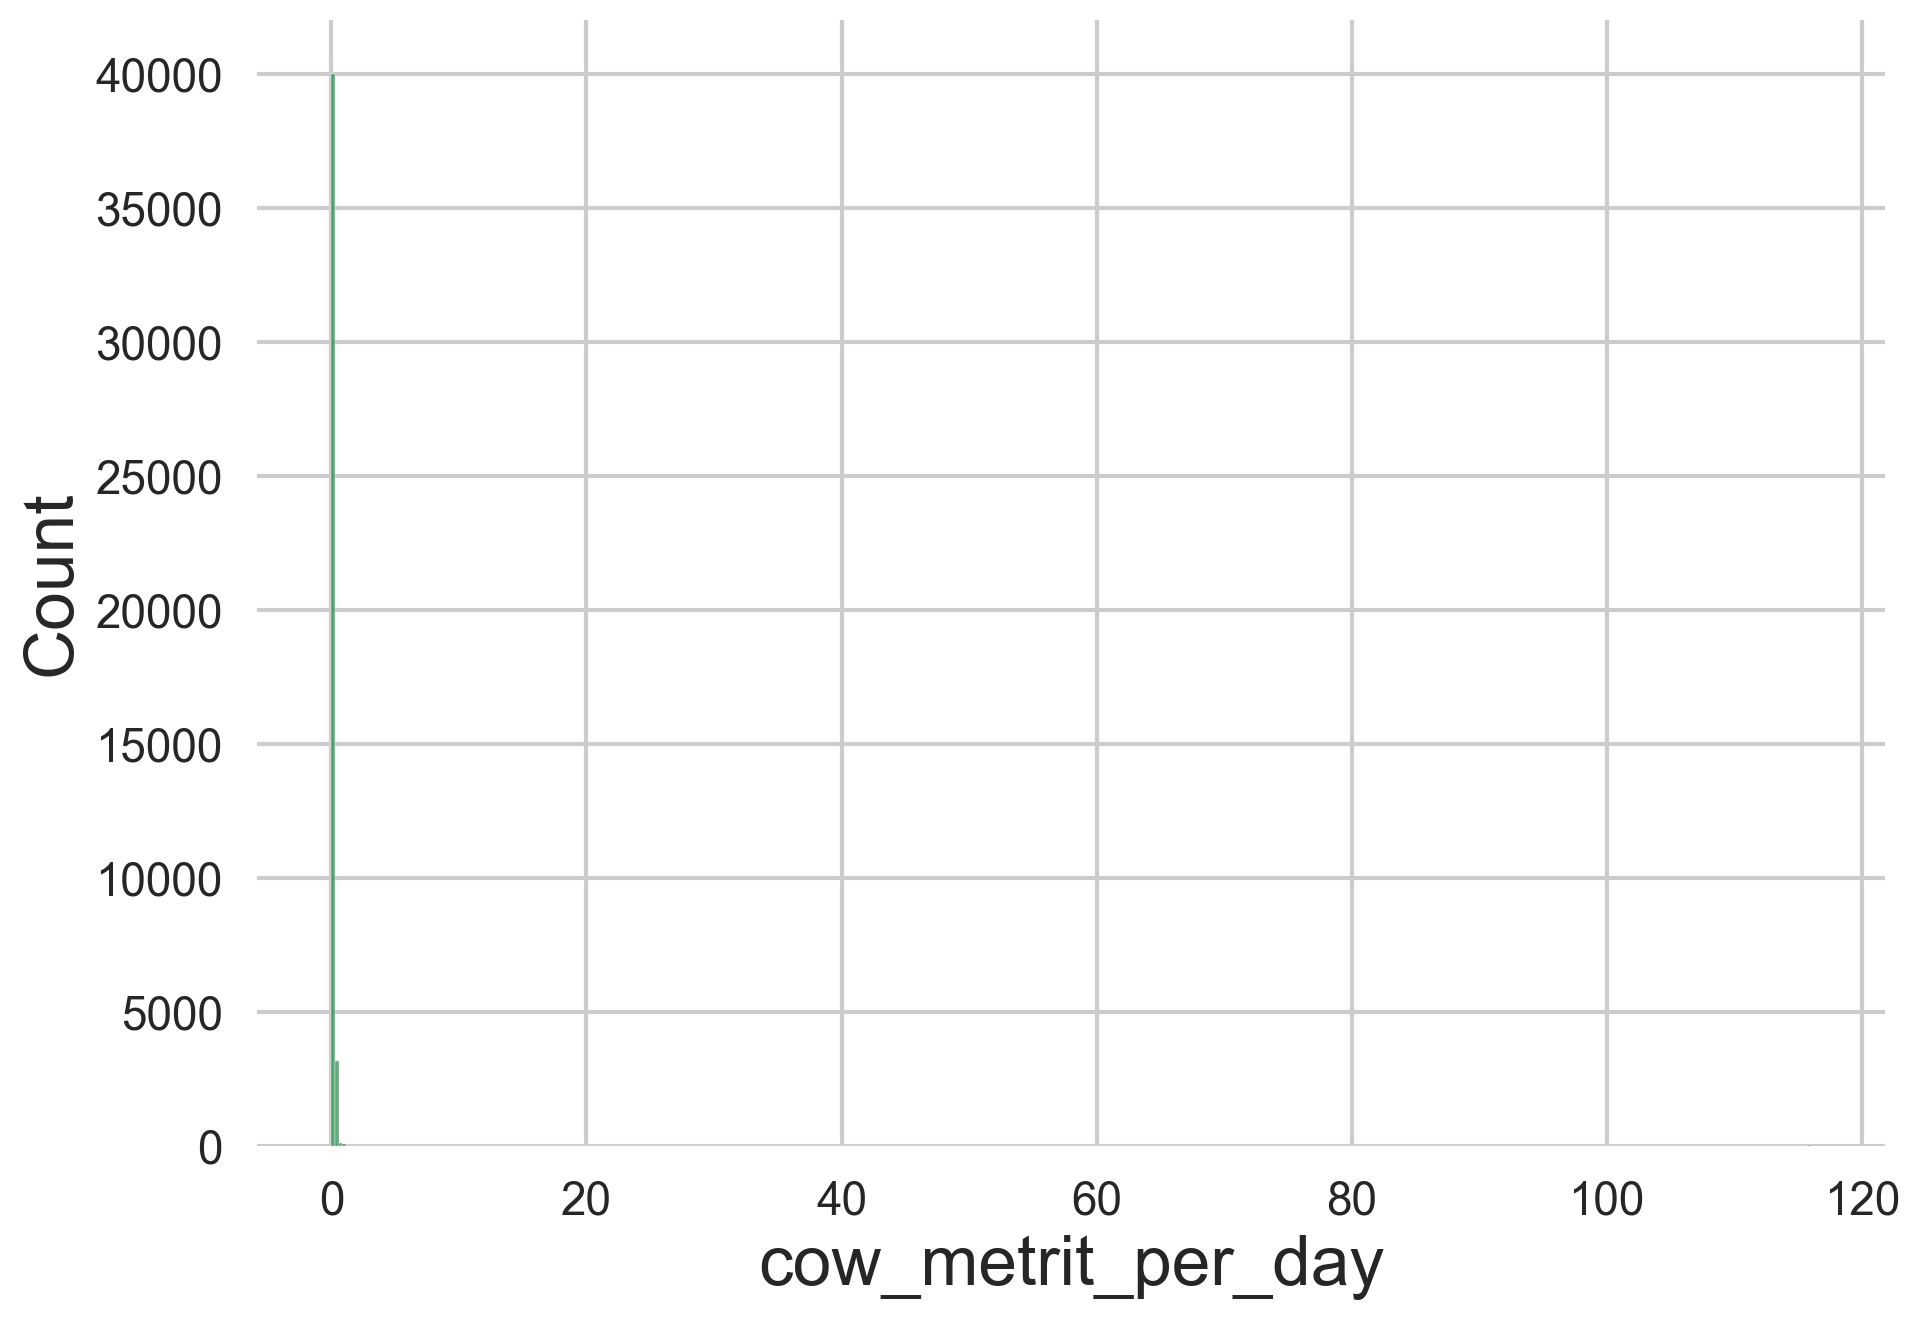

In [332]:
sns.histplot(metrit_daily, x="cow_metrit_per_day")

In [333]:
metrit_daily = metrit_daily[metrit_daily["cow_metrit_per_day"] < 1]

In [334]:
herd_metrics = herd_metrics[~((herd_metrics['calves']==0) & (herd_metrics['cow_metrit']!=0))]

In [335]:
df = pd.read_csv('datasets//FeedingTheTheLast.csv', index_col=0)

In [336]:
metrit_daily

,farm_name,date,calves,metrit,cow_metrit_per_day
70121,ЖК Бобров,2023-01-01,9.612903,1.935484,0.201342
70122,ЖК Бобров,2023-01-02,9.612903,1.935484,0.201342
70123,ЖК Бобров,2023-01-03,9.612903,1.935484,0.201342
70124,ЖК Бобров,2023-01-04,9.612903,1.935484,0.201342
70125,ЖК Бобров,2023-01-05,9.612903,1.935484,0.201342
...,...,...,...,...,...
130134,ЖК Курочкино,2025-07-23,11.580645,2.387097,0.206128
130135,ЖК Курочкино,2025-07-24,11.580645,2.387097,0.206128
130136,ЖК Курочкино,2025-07-25,11.580645,2.387097,0.206128
130137,ЖК Курочкино,2025-07-26,11.580645,2.387097,0.206128


In [337]:
df.rename(columns={'Date': 'date'}, inplace=True)
df['date'] = pd.to_datetime(df['date'])

In [338]:
df_all = df.copy()

In [ ]:
df_all["year_month"] = df_all["date"].dt.to_period("M").astype(str)
herd_metrics["year_month"] = herd_metrics["date"].dt.to_period("M").astype(str)

In [340]:
import pandas as pd
import numpy as np

# Преобразуем даты и сортируем
df_all['date'] = pd.to_datetime(df_all['date'])
df_all = df_all.sort_values(['farm_name', 'date'])

# Список ингредиентов без префиксов
ingredients = sorted({
    c.replace('С1_', '').replace('С2_', '')
    for c in df_all.columns
    if c.startswith('С1_') or c.startswith('С2_')
})

alpha = 0.5  # коэффициент затухания
results = []

for farm, sub in df_all.groupby('farm_name'):
    sub = sub.set_index('date').sort_index()

    for current_date in sub.index:
        window_start = current_date - pd.Timedelta(days=59)
        window = sub.loc[window_start:current_date]

        if len(window) < 60:
            continue

        window = window.sort_index()
        n = len(window)

        # Экспоненциальные веса: старые уменьшаются, новые влияют сильнее
        weights = (1 - alpha) ** np.arange(n-1, -1, -1)
        weights /= weights.sum()  # нормируем, чтобы сумма = 1

        row = {
            "farm_name": farm,
            "date": current_date
        }

        split_idx = n - 15  # первые 45 дней → С1, последние 15 → С2

        for ing in ingredients:
            col_s1 = f"С1_{ing}"
            col_s2 = f"С2_{ing}"

            vals = np.zeros(n)

            if col_s1 in window.columns:
                vals[:split_idx] = window.iloc[:split_idx][col_s1].values
            if col_s2 in window.columns:
                vals[split_idx:] = window.iloc[split_idx:][col_s2].values

            # взвешенная сумма
            row[f"ew_{ing}"] = np.sum(vals * weights)

        results.append(row)

df_ewma = pd.DataFrame(results)


In [341]:
df_ewma

,farm_name,date,ew_Белковые корма,ew_Жидкости,ew_Жиры и глюкозогенные добавки,ew_Комбикорма и стартеры,ew_Минералы/буферные,ew_Объёмные корма,ew_Остатки,ew_Премиксы,ew_Энергетические и крахмалистые корма
0,ЖК Авангард,2023-05-28,2.332511,0.0,0.0,1.290469,0.500337,26.398252,0.0,0.394551,0.819571
1,ЖК Авангард,2023-05-29,2.764166,0.0,0.0,1.418411,0.500161,26.575595,0.0,0.394411,0.873691
2,ЖК Авангард,2023-05-30,2.605466,0.0,0.0,1.347480,0.500074,25.468816,0.0,0.394339,0.862365
3,ЖК Авангард,2023-05-31,2.644162,0.0,0.0,1.486723,0.500030,25.234579,0.0,0.394297,0.898647
4,ЖК Авангард,2023-06-01,2.549737,0.0,0.0,1.479948,0.500008,25.162119,0.0,0.394288,0.873416
...,...,...,...,...,...,...,...,...,...,...,...
41170,ЭФ Родня,2025-07-07,0.000000,0.0,0.0,0.000000,0.000000,0.001426,0.0,0.000000,0.000000
41171,ЭФ Родня,2025-07-08,0.000000,0.0,0.0,0.000000,0.000000,0.001428,0.0,0.000000,0.000000
41172,ЭФ Родня,2025-07-09,0.000000,0.0,0.0,0.000000,0.000000,0.001429,0.0,0.000000,0.000000
41173,ЭФ Родня,2025-07-10,0.000000,0.0,0.0,0.000000,0.000000,0.001429,0.0,0.000000,0.000000


In [342]:
good_df = df_ewma.copy()

In [343]:
good_df = pd.merge(good_df, metrit_daily, on=['date', 'farm_name'], how='inner')

In [344]:
good_df.columns

Index(['farm_name', 'date', 'ew_Белковые корма', 'ew_Жидкости',
       'ew_Жиры и глюкозогенные добавки', 'ew_Комбикорма и стартеры',
       'ew_Минералы/буферные', 'ew_Объёмные корма', 'ew_Остатки',
       'ew_Премиксы', 'ew_Энергетические и крахмалистые корма', 'calves',
       'metrit', 'cow_metrit_per_day'],
      dtype='object')

In [345]:
new_ration_cols = ['ew_Белковые корма', 'ew_Жидкости',
       'ew_Жиры и глюкозогенные добавки', 'ew_Комбикорма и стартеры',
       'ew_Минералы/буферные', 'ew_Объёмные корма', 'ew_Остатки',
       'ew_Премиксы', 'ew_Энергетические и крахмалистые корма']

In [346]:
dff = good_df.merge(herd_metrics[["farm_name", "region"]].drop_duplicates(), on=["farm_name"], how="inner")
dff

,farm_name,date,ew_Белковые корма,ew_Жидкости,ew_Жиры и глюкозогенные добавки,ew_Комбикорма и стартеры,ew_Минералы/буферные,ew_Объёмные корма,ew_Остатки,ew_Премиксы,ew_Энергетические и крахмалистые корма,calves,metrit,cow_metrit_per_day,region
0,ЖК Авангард,2023-05-28,2.332511,0.0,0.0,1.290469,0.500337,26.398252,0.0,0.394551,0.819571,4.290323,0.966667,0.225313,Рязань
1,ЖК Авангард,2023-05-29,2.764166,0.0,0.0,1.418411,0.500161,26.575595,0.0,0.394411,0.873691,4.290323,0.966667,0.225313,Рязань
2,ЖК Авангард,2023-05-30,2.605466,0.0,0.0,1.347480,0.500074,25.468816,0.0,0.394339,0.862365,4.290323,0.966667,0.225313,Рязань
3,ЖК Авангард,2023-05-31,2.644162,0.0,0.0,1.486723,0.500030,25.234579,0.0,0.394297,0.898647,4.290323,0.966667,0.225313,Рязань
4,ЖК Авангард,2023-06-01,2.549737,0.0,0.0,1.479948,0.500008,25.162119,0.0,0.394288,0.873416,5.466667,0.966667,0.176829,Рязань
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31015,МТФ Щучье,2025-07-23,5.041322,0.0,0.0,0.000000,0.000000,45.206313,0.0,0.564444,0.000000,3.645161,0.612903,0.168142,Воронеж
31016,МТФ Щучье,2025-07-24,5.046260,0.0,0.0,0.000000,0.000000,45.167285,0.0,0.564264,0.000000,3.645161,0.612903,0.168142,Воронеж
31017,МТФ Щучье,2025-07-25,5.048738,0.0,0.0,0.000000,0.000000,45.148097,0.0,0.564178,0.000000,3.645161,0.612903,0.168142,Воронеж
31018,МТФ Щучье,2025-07-26,5.049977,0.0,0.0,0.000000,0.000000,45.138503,0.0,0.564135,0.000000,3.645161,0.612903,0.168142,Воронеж


In [347]:
good_df = dff.copy()

### Поиск точки G

In [348]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

target = "cow_metrit_per_day"

num_cols = [
    'ew_Белковые корма', 'ew_Жидкости',
    'ew_Жиры и глюкозогенные добавки', 'ew_Комбикорма и стартеры',
    'ew_Минералы/буферные', 'ew_Объёмные корма', 'ew_Остатки',
    'ew_Премиксы', 'ew_Энергетические и крахмалистые корма'
]

# -----------------------------
# Сначала создаём time_trend
# -----------------------------
df = good_df.copy()
df["date"] = pd.to_datetime(df["date"])
t0 = df["date"].min()
df["time_trend"] = ((df["date"] - t0).dt.days / 30).astype(float)

# -----------------------------
# Теперь dropna
# -----------------------------
df = df.dropna(subset=[target, "region", "date"] + num_cols + ["time_trend"]).copy()

# -----------------------------
# y
# -----------------------------
y = pd.to_numeric(df[target], errors="coerce").clip(0, 1).astype(float)
df = df.loc[y.notna()]
y = y.loc[df.index]

# -----------------------------
# Стандартизация числовых
# -----------------------------
X_num = pd.DataFrame(
    StandardScaler().fit_transform(df[num_cols + ["time_trend"]].astype(float)),
    columns=num_cols + ["time_trend"],
    index=df.index
)

# -----------------------------
# Фиксированные эффекты фермы
# -----------------------------
X_farm = pd.get_dummies(df["region"].astype(str), prefix="farm", drop_first=True).astype(float)

# -----------------------------
# Итоговая матрица X
# -----------------------------
X = pd.concat([X_num, X_farm], axis=1)
X = sm.add_constant(X, has_constant="add").astype(float)

# -----------------------------
# GLM Binomial
# -----------------------------
model = sm.GLM(y, X, family=sm.families.Binomial()).fit()
print(model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:     cow_metrit_per_day   No. Observations:                31020
Model:                            GLM   Df Residuals:                    31004
Model Family:                Binomial   Df Model:                           15
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -9215.5
Date:                 Пн, 15 дек 2025   Deviance:                       761.54
Time:                        00:25:27   Pearson chi2:                     756.
No. Iterations:                     5   Pseudo R-squ. (CS):            0.01140
Covariance Type:            nonrobust                                         
                                             coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

In [349]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

target = "cow_metrit_per_day"
weight_col = "calves"

base_cols = [
    'ew_Белковые корма', 'ew_Жидкости',
    'ew_Жиры и глюкозогенные добавки', 'ew_Комбикорма и стартеры',
    'ew_Минералы/буферные', 'ew_Объёмные корма', 'ew_Остатки',
    'ew_Премиксы', 'ew_Энергетические и крахмалистые корма',
]

df = good_df.dropna(
    subset=[target, weight_col, "region", "date"] + base_cols
).copy()

df["date"] = pd.to_datetime(df["date"])
t0 = df["date"].min()
df["time_trend"] = ((df["date"] - t0).dt.days / 30).astype(float)

y = pd.to_numeric(df[target], errors="coerce").clip(0, 1).astype(float)

w = pd.to_numeric(df[weight_col], errors="coerce")

mask = (y.notna()) & (w > 0)
df = df.loc[mask]
y = y.loc[mask]
w = w.loc[mask]

scaler = StandardScaler()

Z = pd.DataFrame(
    scaler.fit_transform(df[base_cols]),
    columns=base_cols,
    index=df.index
)

Z2 = pd.DataFrame(
    {f"{c}_sq": Z[c] ** 2 for c in base_cols},
    index=df.index
)

X_farm = pd.get_dummies(
    df["region"].astype(str),
    prefix="farm",
    drop_first=True
).astype(float)

X = pd.concat(
    [Z, Z2, df[["time_trend"]], X_farm],
    axis=1
)

X = sm.add_constant(X, has_constant="add")

model = sm.GLM(
    y,
    X,
    family=sm.families.Binomial(),
    freq_weights=w
).fit()

print(model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:     cow_metrit_per_day   No. Observations:                31020
Model:                            GLM   Df Residuals:                359141.94
Model Family:                Binomial   Df Model:                           24
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.0530e+05
Date:                 Пн, 15 дек 2025   Deviance:                       8245.0
Time:                        00:25:27   Pearson chi2:                 8.39e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1523
Covariance Type:            nonrobust                                         
                                                coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

In [350]:

base_cols = [
    'ew_Белковые корма', 'ew_Жидкости',
    'ew_Жиры и глюкозогенные добавки', 'ew_Комбикорма и стартеры',
    'ew_Минералы/буферные', 'ew_Объёмные корма', 'ew_Остатки',
    'ew_Премиксы', 'ew_Энергетические и крахмалистые корма',
]

# Составляем таблицу
rows = []
for c in base_cols:
    coef_lin = model.params.get(c, np.nan)
    pval_lin = model.pvalues.get(c, np.nan)
    
    coef_sq = model.params.get(f"{c}_sq", np.nan)
    pval_sq = model.pvalues.get(f"{c}_sq", np.nan)
    
    rows.append({
        "ew_": c,
        "coeff": coef_lin,
        "pval": pval_lin,
        "ew_ _sq": f"{c}_sq",
        "coeff_sq": coef_sq,
        "pval_sq": pval_sq
    })

ew_table = pd.DataFrame(rows)

# Сортируем по линейному p-value
ew_table_sorted = ew_table.sort_values("pval").reset_index(drop=True)

ew_table_sorted


,ew_,coeff,pval,ew_ _sq,coeff_sq,pval_sq
0,ew_Минералы/буферные,-0.100576,5.806499e-11,ew_Минералы/буферные_sq,0.047057,9.651265e-25
1,ew_Объёмные корма,-0.055491,4.326990e-09,ew_Объёмные корма_sq,-0.041373,8.073168e-44
2,ew_Премиксы,0.097957,2.052266e-08,ew_Премиксы_sq,-0.029706,2.014233e-09
3,ew_Энергетические и крахмалистые корма,-0.067911,4.125547e-06,ew_Энергетические и крахмалистые корма_sq,0.002485,2.047370e-02
4,ew_Белковые корма,-0.057926,1.063433e-04,ew_Белковые корма_sq,-0.009302,5.971804e-02
5,ew_Комбикорма и стартеры,-0.039145,3.766688e-04,ew_Комбикорма и стартеры_sq,0.019510,2.223079e-08
6,ew_Жидкости,-0.020917,1.336070e-02,ew_Жидкости_sq,0.000280,8.988935e-01
7,ew_Остатки,-0.012259,4.484959e-01,ew_Остатки_sq,0.000104,6.074367e-01
8,ew_Жиры и глюкозогенные добавки,0.010069,5.607385e-01,ew_Жиры и глюкозогенные добавки_sq,-0.000068,6.329642e-01


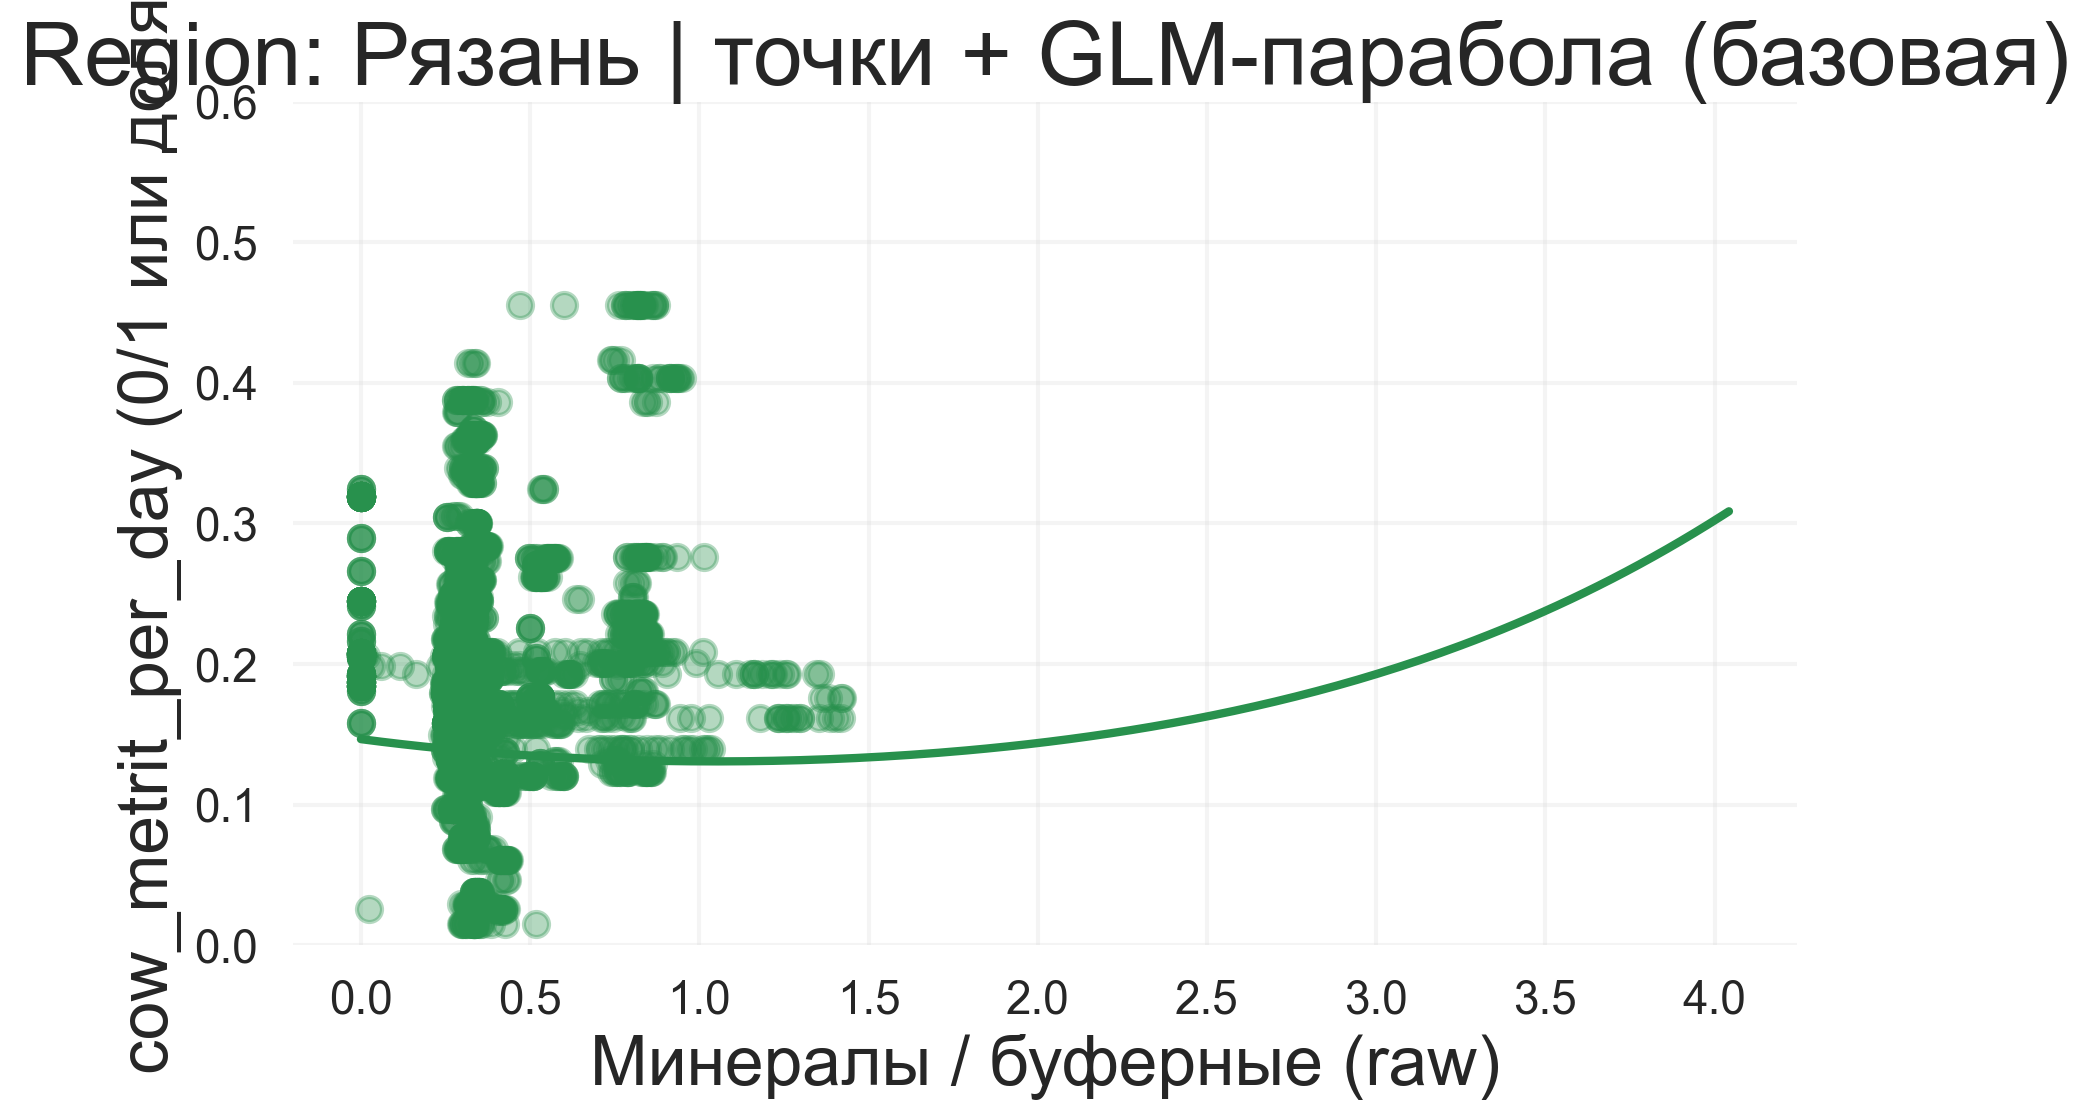

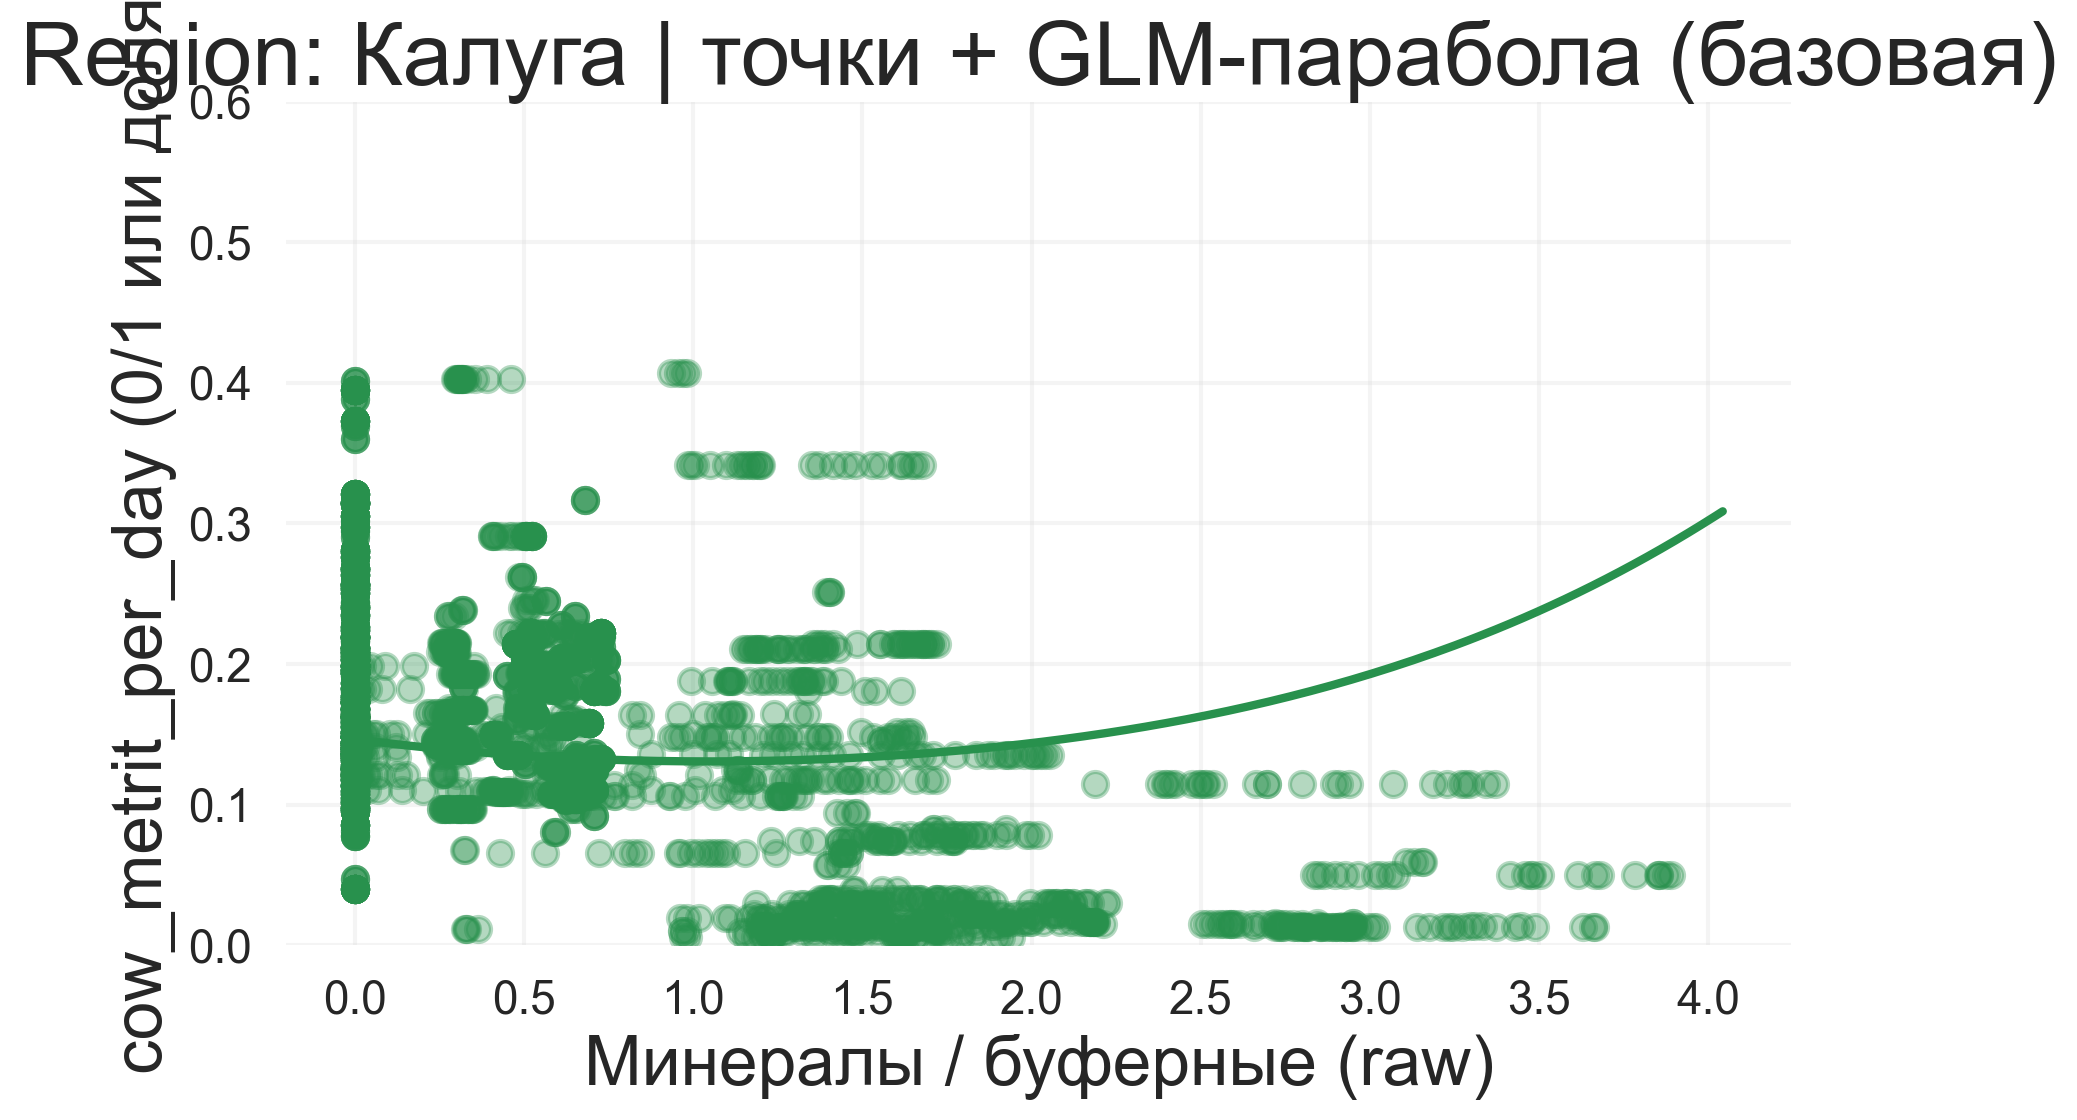

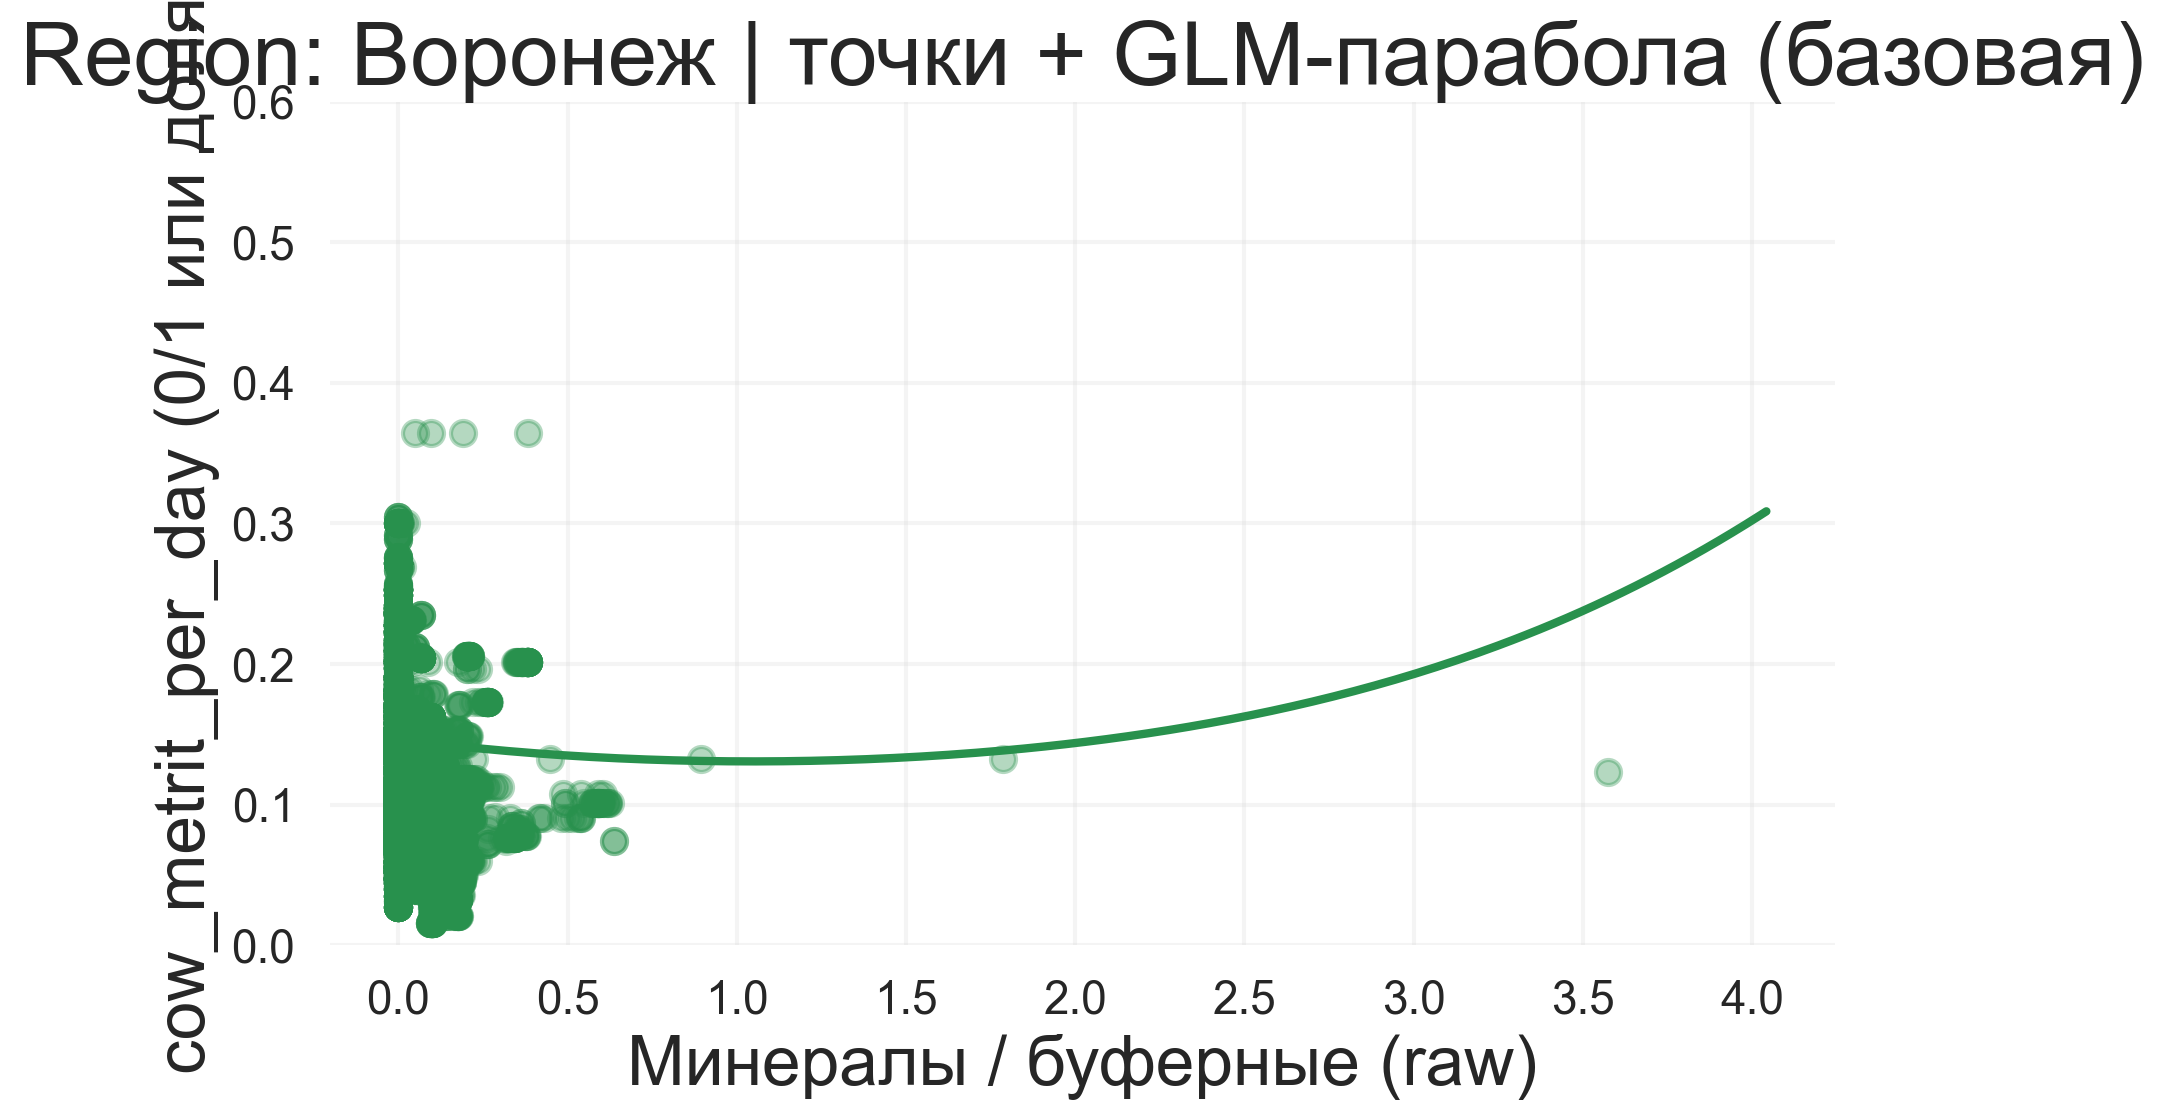

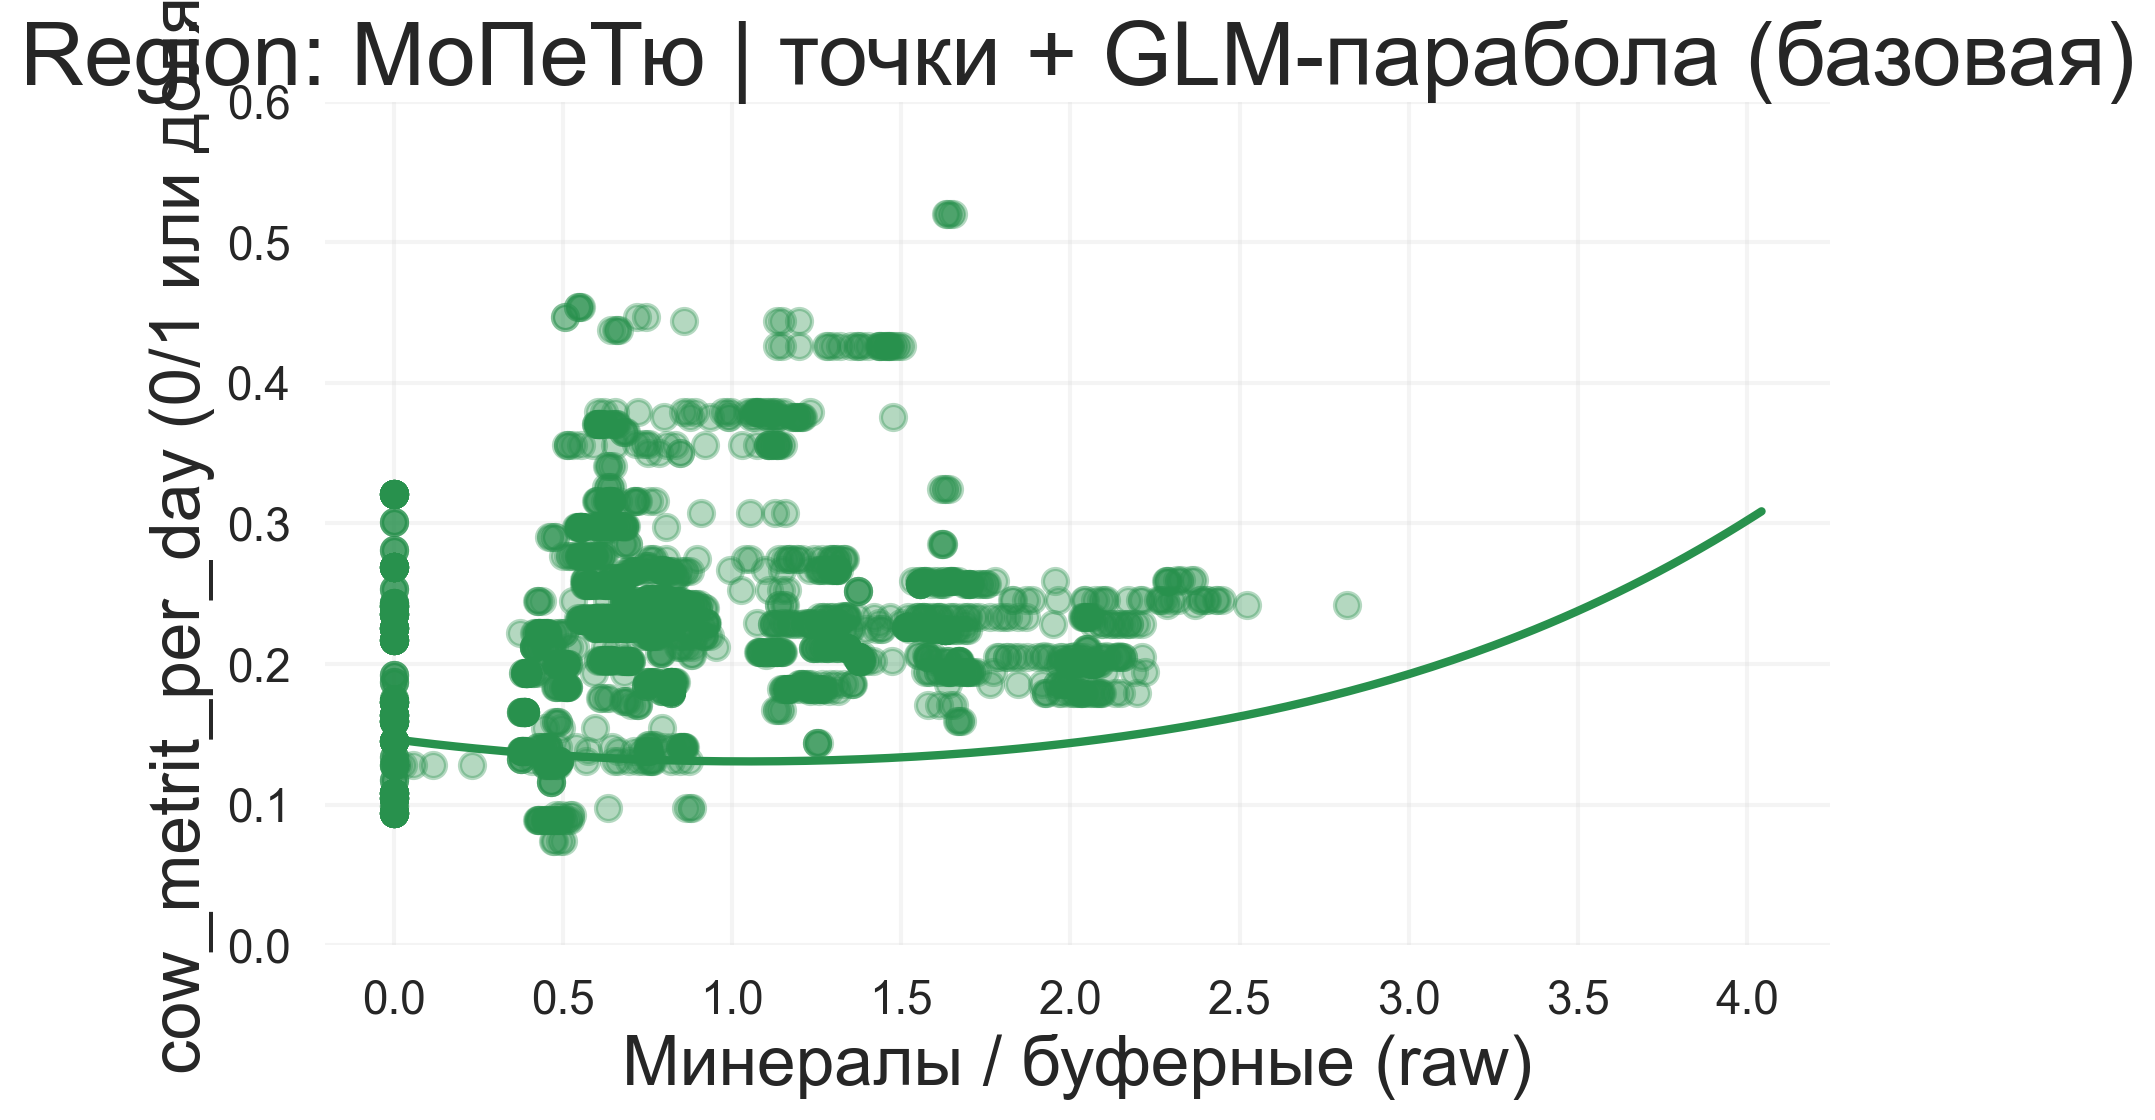

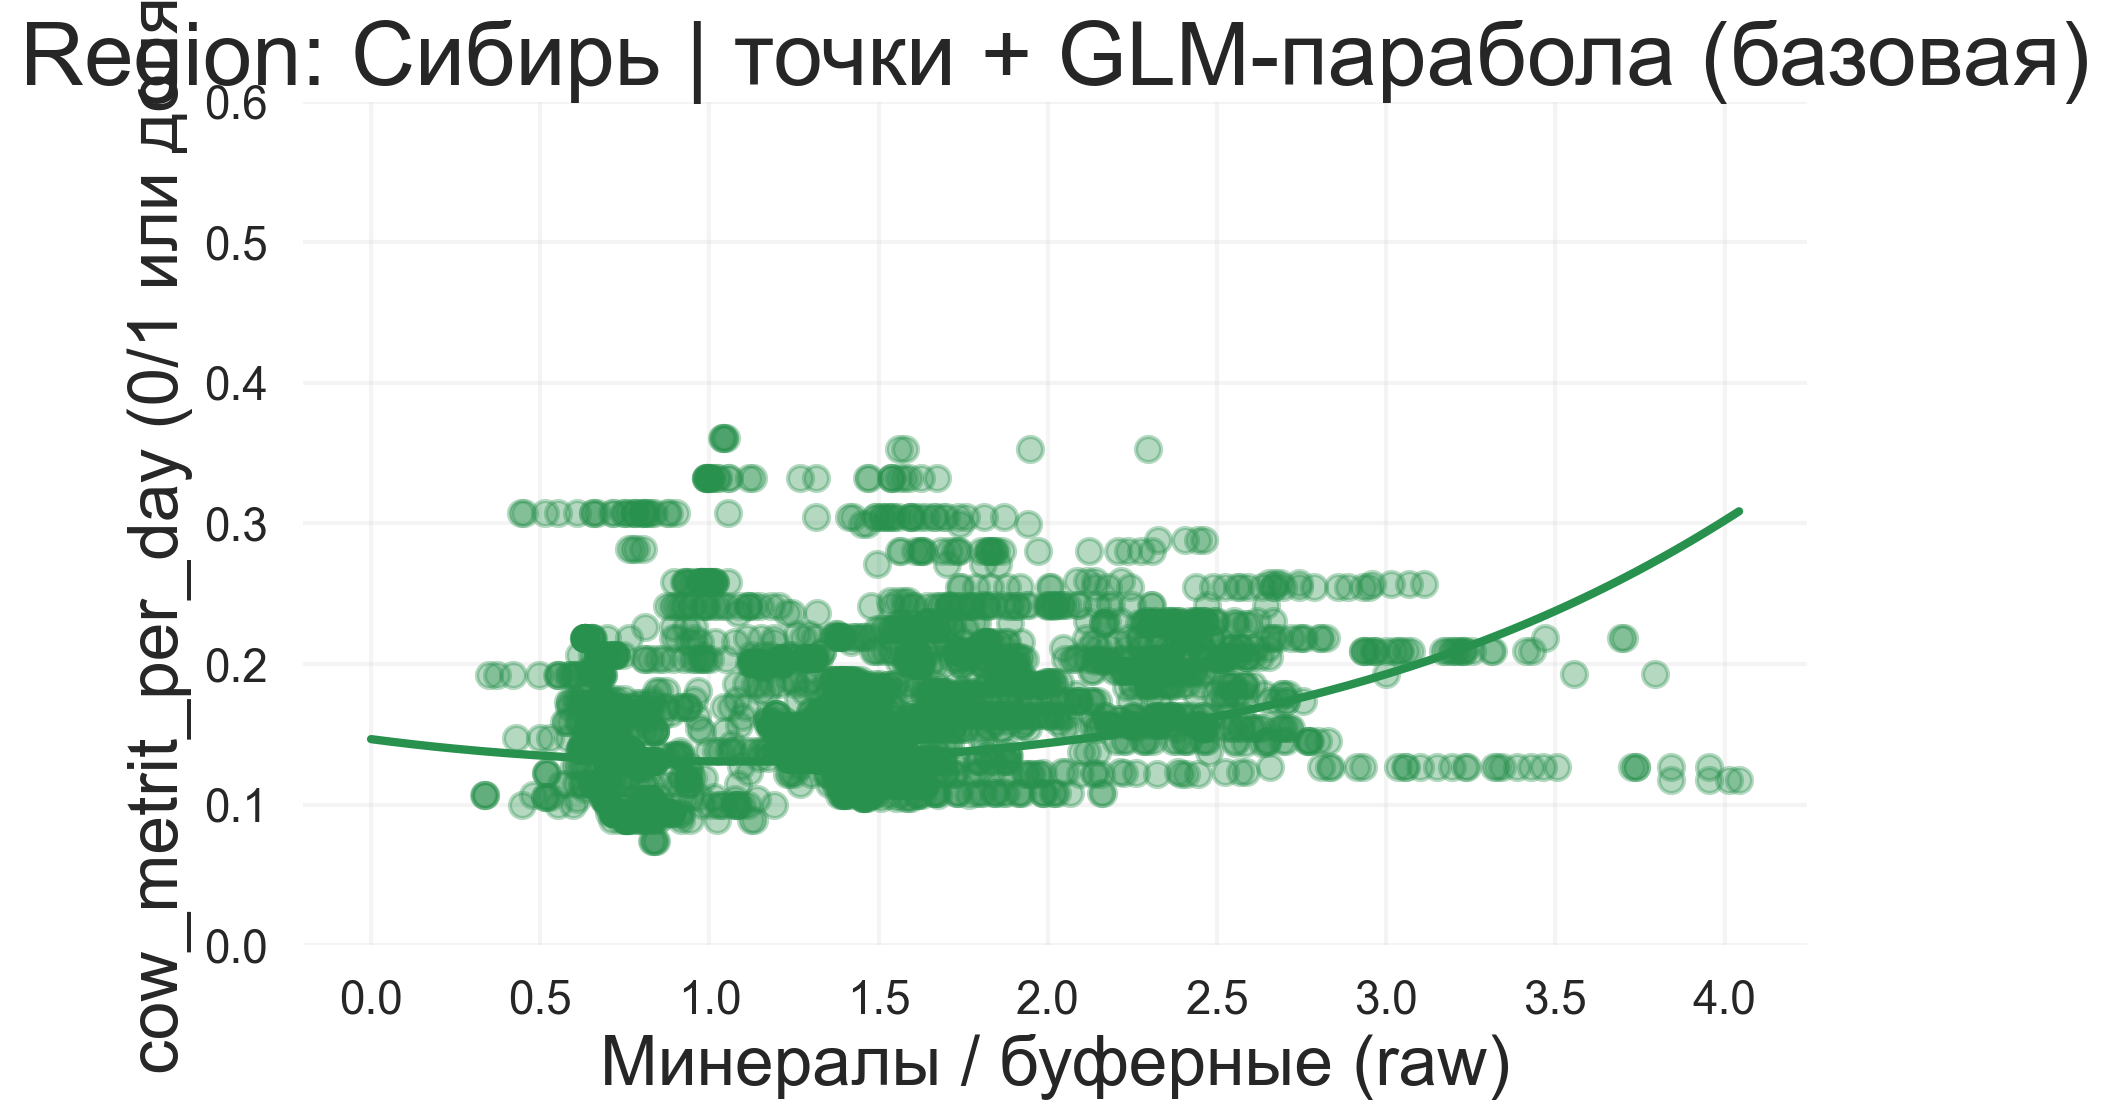

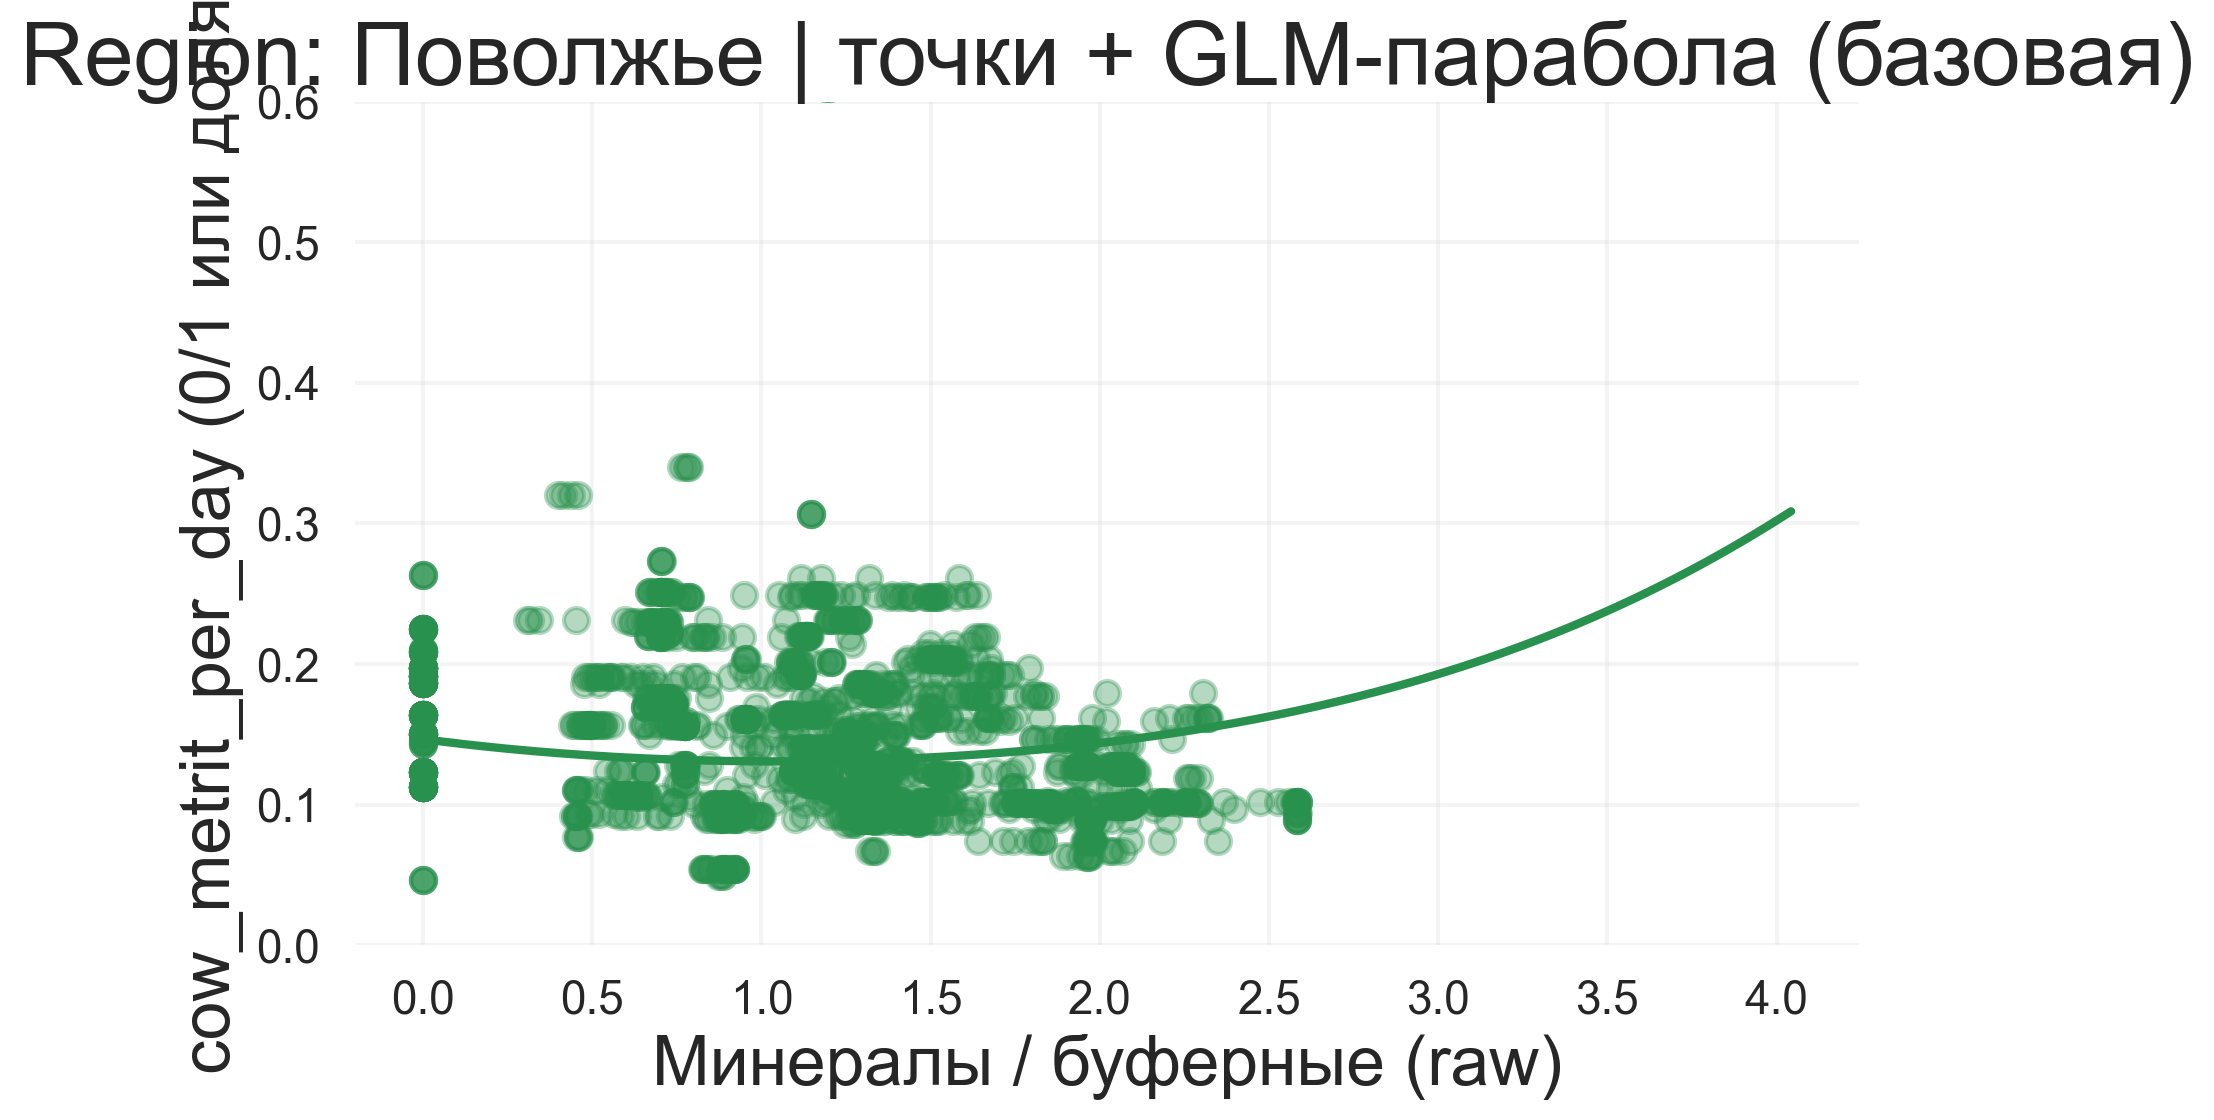

In [351]:
import numpy as np
import matplotlib.pyplot as plt

feat = 'ew_Минералы/буферные'
feat_sq = f'{feat}_sq'

# коэффициенты
b0 = model.params['const']
b1 = model.params[feat]
b2 = model.params[feat_sq]

# сетка по стандартизированному признаку (Z)
z_min, z_max = Z[feat].min(), Z[feat].max()
z_grid = np.linspace(z_min, z_max, 200)

# базовая кривая модели (всё остальное = 0)
linpred = b0 + b1 * z_grid + b2 * z_grid**2
p_grid = 1 / (1 + np.exp(-linpred))

# переведём сетку обратно в исходную шкалу минералов (raw X)
i = base_cols.index(feat)
mu = scaler.mean_[i]
sigma = np.sqrt(scaler.var_[i])
raw_x_grid = mu + z_grid * sigma

# реальные точки
raw_x = df[feat]
raw_y = y

regions = df['region'].astype(str).unique()

for r in regions:
    m = (df['region'].astype(str) == str(r))

    plt.figure(figsize=(9, 6))
    plt.scatter(raw_x[m], raw_y[m], alpha=0.35)
    plt.plot(raw_x_grid, p_grid, lw=3)  # базовая парабола
    plt.xlabel('Минералы / буферные (raw)')
    plt.ylabel('cow_metrit_per_day (0/1 или доля)')
    plt.title(f'Region: {r} | точки + GLM-парабола (базовая)')
    plt.grid(True, alpha=0.2)
    plt.ylim([0, 0.6])
    plt.show()

logit(p) = -1.7618687430599076 + -0.253662062461626 * x + 0.1212001742091268 * x^2


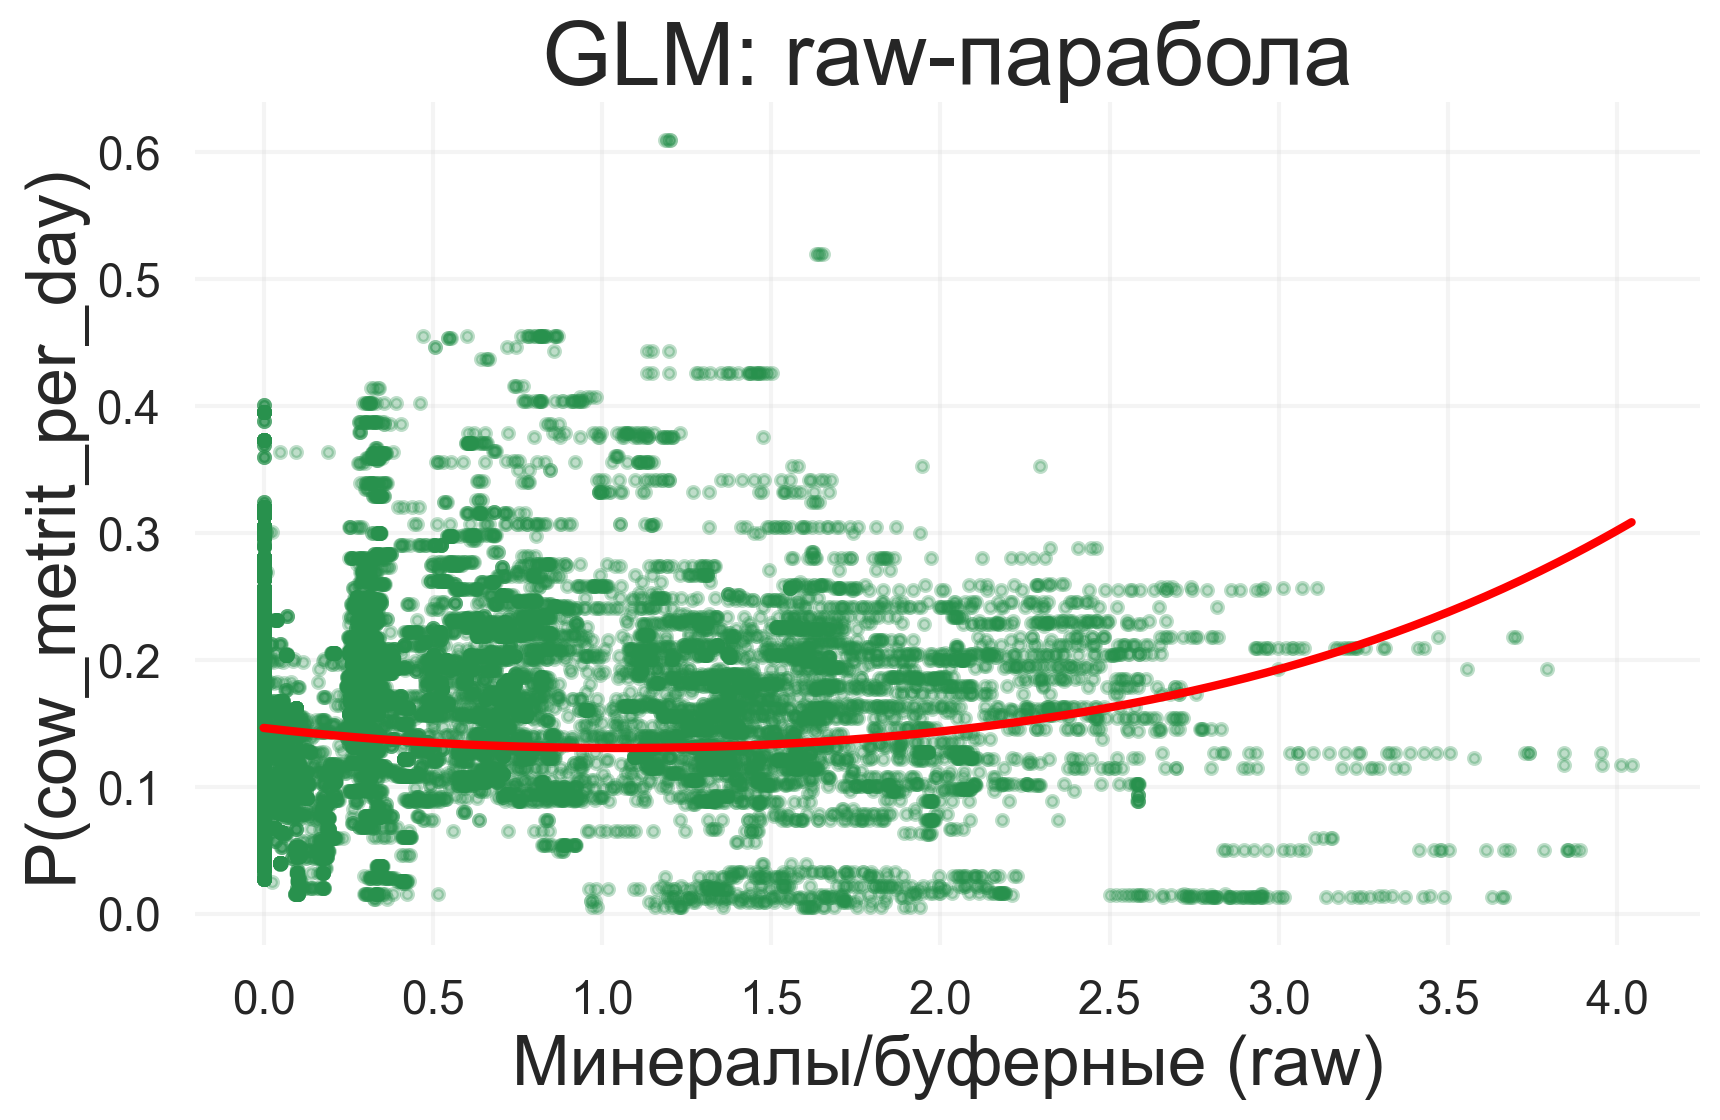

In [352]:
import numpy as np

def raw_parabola_coeffs(model, scaler, feature, base_cols):
    """
    Возвращает (a, b, c) такие, что:
    logit(p) = a + b*x + c*x^2
    где x — raw-признак
    """
    i = base_cols.index(feature)

    mu = scaler.mean_[i]
    sigma = np.sqrt(scaler.var_[i])

    beta0 = model.params['const']
    beta1 = model.params[feature]
    beta2 = model.params[f'{feature}_sq']

    c = beta2 / sigma**2
    b = beta1 / sigma - 2 * mu * beta2 / sigma**2
    a = beta0 - mu * beta1 / sigma + mu**2 * beta2 / sigma**2

    return a, b, c

feat = 'ew_Минералы/буферные'

a, b, c = raw_parabola_coeffs(
    model=model,
    scaler=scaler,
    feature=feat,
    base_cols=base_cols
)

print(f"logit(p) = {a} + {b} * x + {c} * x^2")

x_grid = np.linspace(
    df[feat].min(),
    df[feat].max(),
    300
)

logit = a + b * x_grid + c * x_grid**2
p = 1 / (1 + np.exp(-logit))

plt.figure(figsize=(9, 6))
plt.scatter(df[feat], y, alpha=0.3, s=15)
plt.plot(x_grid, p, lw=3, color="red")
plt.xlabel('Минералы/буферные (raw)')
plt.ylabel('P(cow_metrit_per_day)')
plt.title('GLM: raw-парабола')
plt.grid(True, alpha=0.2)
plt.show()

In [353]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

target = "cow_metrit_per_day"
weight_col = "calves"

base_cols = [
    'ew_Белковые корма', 'ew_Жидкости',
    'ew_Жиры и глюкозогенные добавки', 'ew_Комбикорма и стартеры',
    'ew_Минералы/буферные', 'ew_Объёмные корма', 'ew_Остатки',
    'ew_Премиксы', 'ew_Энергетические и крахмалистые корма',
]
for i in good_df["region"].unique():
    print(f"=========={i}==========")
    df = good_df.dropna(
        subset=[target, weight_col, "region", "date"] + base_cols
    ).copy()
    df = df[df["region"] == i]
    df["date"] = pd.to_datetime(df["date"])
    t0 = df["date"].min()
    df["time_trend"] = ((df["date"] - t0).dt.days / 30).astype(float)

    y = pd.to_numeric(df[target], errors="coerce").clip(0, 1).astype(float)

    w = pd.to_numeric(df[weight_col], errors="coerce")

    mask = (y.notna()) & (w > 0)
    df = df.loc[mask]
    y = y.loc[mask]
    w = w.loc[mask]

    scaler = StandardScaler()

    Z = pd.DataFrame(
        scaler.fit_transform(df[base_cols]),
        columns=base_cols,
        index=df.index
    )

    Z2 = pd.DataFrame(
        {f"{c}_sq": Z[c] ** 2 for c in base_cols},
        index=df.index
    )

    X_farm = pd.get_dummies(
        df["region"].astype(str),
        prefix="farm",
        drop_first=True
    ).astype(float)

    X = pd.concat(
        [Z, Z2, df[["time_trend"]], X_farm],
        axis=1
    )

    X = sm.add_constant(X, has_constant="add")

    model = sm.GLM(
        y,
        X,
        family=sm.families.Binomial(),
        freq_weights=w
    ).fit()

    print(model.summary())


==========Рязань==========
                 Generalized Linear Model Regression Results                  
Dep. Variable:     cow_metrit_per_day   No. Observations:                 3793
Model:                            GLM   Df Residuals:                 39609.71
Model Family:                Binomial   Df Model:                           15
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -13728.
Date:                 Пн, 15 дек 2025   Deviance:                       598.24
Time:                        00:25:29   Pearson chi2:                     602.
No. Iterations:                     5   Pseudo R-squ. (CS):            0.06931
Covariance Type:            nonrobust                                         
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

In [359]:
for farm in good_df['region'].unique():
    print(farm, '-->', good_df[good_df['region'] ==farm].shape[0])

Рязань --> 3793
Калуга --> 5438
Воронеж --> 14964
МоПеТю --> 2209
Сибирь --> 2657
Поволжье --> 1959


In [355]:
good_df

,farm_name,date,ew_Белковые корма,ew_Жидкости,ew_Жиры и глюкозогенные добавки,ew_Комбикорма и стартеры,ew_Минералы/буферные,ew_Объёмные корма,ew_Остатки,ew_Премиксы,ew_Энергетические и крахмалистые корма,calves,metrit,cow_metrit_per_day,region
0,ЖК Авангард,2023-05-28,2.332511,0.0,0.0,1.290469,0.500337,26.398252,0.0,0.394551,0.819571,4.290323,0.966667,0.225313,Рязань
1,ЖК Авангард,2023-05-29,2.764166,0.0,0.0,1.418411,0.500161,26.575595,0.0,0.394411,0.873691,4.290323,0.966667,0.225313,Рязань
2,ЖК Авангард,2023-05-30,2.605466,0.0,0.0,1.347480,0.500074,25.468816,0.0,0.394339,0.862365,4.290323,0.966667,0.225313,Рязань
3,ЖК Авангард,2023-05-31,2.644162,0.0,0.0,1.486723,0.500030,25.234579,0.0,0.394297,0.898647,4.290323,0.966667,0.225313,Рязань
4,ЖК Авангард,2023-06-01,2.549737,0.0,0.0,1.479948,0.500008,25.162119,0.0,0.394288,0.873416,5.466667,0.966667,0.176829,Рязань
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31015,МТФ Щучье,2025-07-23,5.041322,0.0,0.0,0.000000,0.000000,45.206313,0.0,0.564444,0.000000,3.645161,0.612903,0.168142,Воронеж
31016,МТФ Щучье,2025-07-24,5.046260,0.0,0.0,0.000000,0.000000,45.167285,0.0,0.564264,0.000000,3.645161,0.612903,0.168142,Воронеж
31017,МТФ Щучье,2025-07-25,5.048738,0.0,0.0,0.000000,0.000000,45.148097,0.0,0.564178,0.000000,3.645161,0.612903,0.168142,Воронеж
31018,МТФ Щучье,2025-07-26,5.049977,0.0,0.0,0.000000,0.000000,45.138503,0.0,0.564135,0.000000,3.645161,0.612903,0.168142,Воронеж
